# Accommodation scan: conditional mean-curvature allocation

Train on exclusive fate identities to allocate curvature **given each organoid's measured mean**, optionally also its measured SD. The target is either `H − mean(H)` (`mean_only`) or `(H − mean(H))/SD(H)` (`standardized`). Held-out summary statistics are supplied deliberately: this is conditional reconstruction, not shape prediction from fate alone. No cell-level curvature enters the predictor.

The energy prediction solves `(I + gamma L) h = u − mean(u)`, with equal-cell graph Laplacian `L` and local preference `u = a_center + sum of selected presence interactions`. Coefficients and gamma are constant across N. Presence counts a source identity once anywhere in the chosen range, not once per cell; radius 0 disables pairs while retaining accommodation. No training-reference activation centering is used.

Data filters, folds, target cleanup, normalization and fitting settings are exposed below. Spherical-like organoids never enter fitting. Every comparison uses identical inner/outer memberships. Pair regularization is selected only on the inner training split. Predictions, models, exact memberships, physical targets, moments and settings are stored together. Mean-only coefficients have physical curvature units; mean+SD coefficients have standardized units. Their common center offset is arbitrary after output centering.

This notebook scans accommodation; use energy_model_evaluation.ipynb for overall/regional MSE and coefficient profiles.

In [1]:
from pathlib import Path
import sys
import copy
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import attach_metadata_to_graphs, load_aux_metadata_for_dir, load_marker_names_from_dir
from src.data.filters import filter_graphs_by_timepoints, filter_graphs_by_blacklist, load_graph_blacklist_from_dir, filter_graphs_by_numeric_metadata, filter_graphs_by_sphericity
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES
from src.models.size_models import seed_all
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy_fixed
from src.training.progress import TrainingProgress
from src.analysis.spatial.regions import distance_regions
from src.artifacts.bundle import save_bundle, load_bundle, graph_membership
from src.artifacts.paths import training_run_path
from src.artifacts.provenance import workflow_fingerprint
from torch_geometric.loader import DataLoader
from src.models.gnn import GINCurvature
from src.inference.predict import predict_targets
from src.data.target_transforms import ObservedGraphMoments, center_graph_values
from dataclasses import asdict


## Settings
Choose normalization modes, data filters and model configurations before loading data. A fresh timestamped run is created unless RESUME_RUN is specified.

In [2]:
# Execution and device
RUN_TRAINING = True  # Enable fitting; running the notebook trains all configured models.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # CUDA for graph solves and GIN when available.
SHOW_PROGRESS = True  # Show model, fold and completed tasks.
RESUME_RUN = None  # Existing incomplete run with identical settings, or None for a fresh output.

SETTINGS = dict(
    # Run identity and dataset
    tag='conditional_scan',  # Optional purpose label in the output folder.
    dataset='after_cleanup',  # Original graph dataset under training_data/.
    target_indices=[1],  # Mean curvature only; 0 denotes Gaussian curvature in the dataset.
    strict_loading=True,  # Raise on invalid graph files rather than silently skipping them.

    # Shared cohort selection
    timepoints=['day4', 'day4p5', 'day4p5-more'],  # All currently available labels at day 4 or later.
    blacklist=True,  # Exclude blacklisted organoids before making either cohort.
    sphericity_max=.93,  # Ordinary cohort: q<cutoff; spherical validation: q>=cutoff.
    complexity_min=None,  # Optional minimum complexity, applied to both cohorts.
    exclusive_markers=True,  # Required: sequential exclusive fate rules; all-zero is Unassigned.

    # Ordinary train/validation split
    n_folds=5,  # 1: single holdout; larger values: disjoint validation folds.
    val_fraction=.2,  # Ordinary validation fraction when n_folds=1.
    split_seed=42,  # Reproducible organoid membership; spherical organoids are never split into training.

    # Target cleanup (thresholds learned only on ordinary training organoids)
    interpolate_outliers=True,  # Apply the same training-fitted cleanup to all evaluation cohorts.
    outlier_quantiles=[.005, .995],  # Global training quantiles identifying extreme target values.
    outlier_min_neighbors=1,  # Minimum usable neighbors for interpolation.
    outlier_max_hops=2,  # Target cleanup radius, distinct from model interaction radius.
    outlier_interpolation='quadratic',  # Quadratic or mean neighbor interpolation.
    outlier_ridge=.001,  # Quadratic interpolation regularizer.
    reject_farther_outliers=True,  # Reject replacements that worsen outlier severity.
    outlier_fallback='neighbor_mean',  # Fallback for under-supported interpolation.

    # Target normalization: measured moments are used only outside the predictor
    target_modes=['mean_only', 'standardized'],  # Choose either or both: subtract mean; subtract mean and divide by SD.
    std_floor_fraction=.1,  # Inner-training median SD times this value sets the relative floor.
    std_floor_absolute=1e-6,  # Minimum allowed physical SD for stable normalization.
    zero_mean_output=True,  # Remove predicted graph mean inside fitting and inference.
    variance_ddof=0,  # Population variance with equal weight per cell.

    # Coefficient fitting and training-only regularization selection
    center_ridge=.0001,  # Center preference penalty in training-target RMS units.
    pair_ridge_grid=[.0001, .001],  # Select pair penalty on inner training holdout, then refit.
    min_pair_organoids=20,  # Support flag, never silently removes a pair.
    inner_fraction=.2,  # Training-only holdout shared across models and normalization modes.
    inner_seed=42,  # Reproducible inner memberships.
    solver_rtol=1e-11,  # Relative tolerance for CUDA accommodation solves.
    blas_threads=4,  # CPU linear algebra and torch threads.

    # Accommodation scan and local model
    gamma_grid=[0., .1, .2, .4, .5, .8, 1.6, 3.2, 6.4, 12.8, 25.6],  # Fixed values; outer validation never selects coefficients.
    interaction_radius=1,  # Supported direct ranges: 1 or 2; accommodation acts over the graph.
    source_markers=None,  # None: all identities, including Unassigned; otherwise list source names.
    recipient_markers=None,  # None: all center identities; otherwise list recipient names.
    interaction_pairs=None,  # None: selected panels' Cartesian product; otherwise [(recipient, source), ...].

)

# Regional evaluation; labels do not enter model inputs
REGION_SETTINGS = dict(
    crypt_max=.75,  # Crypt interior: s<0.75 regardless of neck qualification.
    neck_max=1.1,  # Qualified neck: 0.75<=s<1.1; villus: s>=1.1.
    crypt_marker='LGR5',  # Split crypts by LGR5 presence anywhere in their assigned interior.
    neck_config=dict(
        minimum_crypt_cells=0,  # No extra crypt-size qualification.
        minimum_relative_depth=.05,  # Circumference trough depth threshold.
        plateau_max_range=.10,  # Maximum relative circumference range for a plateau.
        plateau_max_slope=.25,  # Maximum relative plateau slope.
        plateau_exit_rise=.10,  # Required rise after a plateau.
        minimum_window=[.8, 1.2],  # Search interval for a local circumference minimum.
        plateau_window=[.85, 1.15],  # Interval used to test a flat circumference segment.
        smoothing_points=7,  # Odd Savitzky–Golay profile smoothing window.
    ),
)


NOTEBOOK_NAME = 'energy_model_training'  # Output namespace matching this notebook.
RUN_DIR = Path(RESUME_RUN) if RESUME_RUN else training_run_path(PROJECT_ROOT, NOTEBOOK_NAME, SETTINGS['tag'])  # Saved artifacts.


## Load and filter the data
Apply the same timepoints, blacklist and complexity filters to all cohorts. Separate sphericity ≥0.93 into held-out validation and apply exclusive fate rules.

In [3]:
if SETTINGS['target_indices']!=[1] or not SETTINGS['exclusive_markers']:
    raise ValueError('Use mean curvature and exclusive identities for this workflow.')
if not SETTINGS['target_modes'] or not set(SETTINGS['target_modes'])<={'mean_only','standardized'} or len(set(SETTINGS['target_modes']))!=len(SETTINGS['target_modes']):
    raise ValueError('Select distinct target_modes from mean_only and standardized.')
if SETTINGS['variance_ddof']!=0 or not SETTINGS['zero_mean_output']:
    raise ValueError('Population SD and graph-mean output projection are required.')
if not np.isfinite(SETTINGS['sphericity_max']) or not 0<SETTINGS['sphericity_max']<=1:
    raise ValueError('A sphericity cutoff in (0,1] is required.')
torch.set_num_threads(SETTINGS['blas_threads'])
data_dir=PROJECT_ROOT/'training_data'/SETTINGS['dataset']
graphs=load_graph_dataset_from_dir(str(data_dir),strict=SETTINGS['strict_loading'],target_indices=SETTINGS['target_indices'])
attach_metadata_to_graphs(graphs,load_aux_metadata_for_dir(str(data_dir)),exclude_keys=None)
marker_names=load_marker_names_from_dir(str(data_dir))
if not marker_names:raise ValueError('Dataset must supply named fate channels.')
identity_names=list(marker_names)+['Unassigned']
available={str(g.meta.get('timepoint')) for g in graphs}
if SETTINGS['timepoints'] is not None and set(SETTINGS['timepoints'])-available:
    raise ValueError(f'Unknown requested timepoints: {set(SETTINGS["timepoints"])-available}')
graphs=filter_graphs_by_timepoints(graphs,SETTINGS['timepoints'],print_summary=True)
if SETTINGS['blacklist']:
    graphs=filter_graphs_by_blacklist(graphs,load_graph_blacklist_from_dir(data_dir),print_summary=True)
if SETTINGS['complexity_min'] is not None:
    graphs=filter_graphs_by_numeric_metadata(graphs,key='complexity',min_value=SETTINGS['complexity_min'],allow_missing=False,print_summary=True)
ordinary,rejected,sphericity=filter_graphs_by_sphericity(graphs,max_sphericity=SETTINGS['sphericity_max'],allow_missing=False,return_rejected=True,return_scores=True,print_summary=True)
q_by_id={str(g.organoid_str):float(q) for g,q in zip(graphs,sphericity)}
spherical=[g for g in rejected if np.isfinite(q_by_id[str(g.organoid_str)]) and q_by_id[str(g.organoid_str)]>=SETTINGS['sphericity_max']]
invalid=[g for g in rejected if not np.isfinite(q_by_id[str(g.organoid_str)])]
print('Separate spherical validation:',len(spherical),'| invalid sphericity metadata excluded:',len(invalid))
for g in ordinary+spherical:
    g.x=torch.as_tensor(exclusive_markers(g.x.cpu().numpy(),marker_names),dtype=g.x.dtype)
    if not torch.isfinite(g.y).all():raise ValueError(f'Nonfinite mean curvature: {g.organoid_str}')
if len(ordinary)<5:raise ValueError('Need at least five ordinary organoids for outer and inner splitting.')
if not spherical:print('No eligible spherical organoids; ordinary validation remains available.')
raw_graphs={str(g.organoid_str):g for g in ordinary+spherical}
if len(raw_graphs)!=len(ordinary)+len(spherical):raise ValueError('Duplicate organoid identifiers.')
cohort=pd.DataFrame([dict(organoid_str=str(g.organoid_str),cohort=role,timepoint=str(g.meta.get('timepoint','unknown')),N=len(g.x),sphericity=q_by_id[str(g.organoid_str)]) for role,group in [('ordinary',ordinary),('spherical',spherical)] for g in group])
display(cohort.groupby(['timepoint','cohort']).agg(organoids=('organoid_str','size'),median_N=('N','median')))

Loaded 1500 graphs; skipped 0.


filter_graphs_by_metadata(key='timepoint'): kept 1210 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_blacklist(n_keys=17): kept 1193 / 1210 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                330    342    0.965
20250929         day4p5              112    113    0.991
20250929         day4p5-more         475    477    0.996
20251201         day4p5              276    278    0.993
filter_graphs_by_sphericity(max_sphericity=0.93): kept 869 / 1193 graphs

dataset          timepoint          kept  total 

organoids  median_N
timepoint   cohort                        
day4        ordinary         233     318.0
            spherical         97     194.0
day4p5      ordinary         288     425.5
            spherical        100     122.5
day4p5-more ordinary         348     529.0
            spherical        127     213.0

## Folds and anatomical regions
Create reproducible organoid splits. Regions come directly from crypt geometry; spherical-like organoids and organs without detected crypts share one category. Unqualified boundary cells remain in overall MSE but have no regional panel.

In [4]:
rng=np.random.default_rng(SETTINGS['split_seed']);order=rng.permutation(len(ordinary))
f=SETTINGS['n_folds']
if not isinstance(f,int) or not 1<=f<=len(ordinary):raise ValueError('Invalid fold count.')
if not 0<SETTINGS['val_fraction']<1:raise ValueError('val_fraction must be between zero and one.')
validation_sets=[order[:max(1,min(len(order)-4,round(len(order)*SETTINGS['val_fraction'])))]] if f==1 else np.array_split(order,f)
splits=[];membership=[]
for fold,val in enumerate(validation_sets):
    train=np.setdiff1d(order,val)
    if len(train)<4 or not len(val):raise ValueError('Each fold needs at least four training organoids and nonempty validation.')
    splits.append(dict(fold=fold,train_indices=train.tolist(),val_indices=val.tolist()))
    membership.append(dict(fold=fold,**graph_membership(train=[ordinary[i] for i in train],validation=[ordinary[i] for i in val]),spherical_validation=[str(g.organoid_str) for g in spherical]))
display(pd.DataFrame([dict(fold=s['fold'],train=len(s['train']),validation=len(s['validation']),spherical_validation=len(s['spherical_validation'])) for s in membership]))
region_rows=[]
for role,group in [('ordinary',ordinary),('spherical',spherical)]:
    for g in group:
        if role=='spherical':
            table=pd.DataFrame(dict(organoid_str=str(g.organoid_str),node=np.arange(len(g.x)),region='spherical_validation',annotation_status='cohort_override'))
        else:
            table=distance_regions(g,data_dir,marker_names=marker_names,**REGION_SETTINGS)
        table['original_region']=table.region
        table['cohort']=role
        table.loc[table.region.isin(['spherical_validation','no_detected_crypt']),'region']='spherical_or_no_detected_crypt'
        table.loc[table.region=='boundary_without_qualified_neck','region']='excluded_boundary'
        region_rows.append(table)
regions=pd.concat(region_rows,ignore_index=True)
display(regions.groupby(['cohort','region']).size().rename('cells').to_frame())


,fold,train,validation,spherical_validation
0,0,695,174,324
1,1,695,174,324
2,2,695,174,324
3,3,695,174,324
4,4,696,173,324


cells
cohort    region                                
ordinary  crypt_with_LGR5                  59687
          crypt_without_LGR5               31232
          excluded_boundary                62139
          neck                             28049
          spherical_or_no_detected_crypt   24393
          villus                          214242
spherical spherical_or_no_detected_crypt   70771

## Physical targets and observed moments
Fit cleanup thresholds on outer training only. Compute per-organoid mean and population SD after cleanup; the SD floor is determined only on inner training organoids. Save the raw cohort and each prepared fold for independent analysis.

In [5]:
if not RUN_TRAINING:
    raise RuntimeError('Settings inspected. Set RUN_TRAINING=True to fit.')
config=dict(SETTINGS,region_settings=REGION_SETTINGS,device=DEVICE,
    task='Conditional curvature allocation given measured organoid mean and optional SD',
    baseline_subtraction=False,global_features=[],output_projection='graph_mean')
if RUN_DIR.exists():
    if json.loads((RUN_DIR/'settings.json').read_text())!=config:
        raise ValueError('Resume settings differ; use a new run.')
    if json.loads((RUN_DIR/'splits.json').read_text())!=membership:
        raise ValueError('Resume memberships differ.')
else:
    RUN_DIR.mkdir(parents=True)
    (RUN_DIR/'settings.json').write_text(json.dumps(config,indent=2))
    (RUN_DIR/'splits.json').write_text(json.dumps(membership,indent=2))
    (RUN_DIR/'exclusivity_rules.json').write_text(json.dumps(EXCLUSIVITY_RULES,indent=2))
    cohort.to_csv(RUN_DIR/'cohort.csv',index=False)
    regions.to_csv(RUN_DIR/'regions.csv.gz',index=False)
    save_bundle(RUN_DIR/'cohort',dict(raw_graphs=raw_graphs,all_marker_names=marker_names,settings=config),splits=membership)
for folder in ['history','predictions']:(RUN_DIR/folder).mkdir(exist_ok=True)
records=json.loads((RUN_DIR/'models.json').read_text()) if (RUN_DIR/'models.json').exists() else []
cleanup_options=dict(clip_quantiles=SETTINGS['outlier_quantiles'],min_neighbors=SETTINGS['outlier_min_neighbors'],
    max_hops=SETTINGS['outlier_max_hops'],interpolation=SETTINGS['outlier_interpolation'],ridge=SETTINGS['outlier_ridge'],
    reject_farther_outliers=SETTINGS['reject_farther_outliers'],fallback=SETTINGS['outlier_fallback'],report=False)
moment_rows=[]
for split in membership:
    fold=split['fold'];input_path=RUN_DIR/f'inputs/fold_{fold}_mean'
    if input_path.exists():
        prepared=load_bundle(input_path)
    else:
        train=[raw_graphs[oid] for oid in split['train']]
        held=[raw_graphs[oid] for oid in split['validation']+split['spherical_validation']]
        if SETTINGS['interpolate_outliers']:
            train,cleanup=interpolate_target_outliers_from_neighbors(train,**cleanup_options)
            held,_=interpolate_target_outliers_from_neighbors(held,fitted_statistics=cleanup,**cleanup_options)
        else:
            train=copy.deepcopy(train);held=copy.deepcopy(held);cleanup=None
        nv=len(split['validation'])
        physical_groups=dict(train=train,val=held[:nv],spherical=held[nv:])
        for group in physical_groups.values():
            for graph in group:
                graph.y=graph.y.reshape(-1).double()
                if 'global_feat' in graph:del graph['global_feat']
        order=np.random.default_rng(SETTINGS['inner_seed']).permutation(len(train))
        ninner=max(1,min(len(train)-2,round(SETTINGS['inner_fraction']*len(train))))
        inner_train=[str(train[i].organoid_str) for i in order[ninner:]]
        inner_validation=[str(train[i].organoid_str) for i in order[:ninner]]
        training_std=[float(train[i].y.std(correction=0)) for i in order[ninner:]]
        floor=max(SETTINGS['std_floor_absolute'],SETTINGS['std_floor_fraction']*float(np.median(training_std)))
        moments={str(g.organoid_str):ObservedGraphMoments.from_targets(g.y.numpy(),std_floor=floor)
                 for group in physical_groups.values() for g in group}
        prepared=dict(physical_groups=physical_groups,moments=moments,std_floor=floor,marker_names=marker_names,
            outlier_info=cleanup,inner_train=inner_train,inner_validation=inner_validation,conditional_reconstruction=True)
        save_bundle(input_path,prepared,splits=split,provenance=dict(observed_heldout_moments=True))
    for role,group in prepared['physical_groups'].items():
        for graph in group:
            moment_rows.append(dict(fold=fold,cohort=role,organoid_str=str(graph.organoid_str),**asdict(prepared['moments'][str(graph.organoid_str)])))
pd.DataFrame(moment_rows).to_csv(RUN_DIR/'observed_moments.csv',index=False)
print('Prepared:',RUN_DIR,'| device:',DEVICE)


Prepared: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/conditional_scan_20261002_162217 | device: cuda


## Fit energy models
For every requested mode, fold and accommodation, solve the regularized linear coefficient fit. Only shrinkage is selected on the inner holdout. Refit on full outer training and export held-out predictions in physical and standardized units.

In [6]:
gammas=np.asarray(SETTINGS['gamma_grid'],float)
if not len(gammas) or not np.isfinite(gammas).all() or np.any(gammas<0) or np.any(np.diff(gammas)<=0):
    raise ValueError('Use a strictly increasing finite nonnegative accommodation grid.')
model_specs=[dict(name='presence_energy',family='energy',radius=SETTINGS['interaction_radius'],
    sources=SETTINGS['source_markers'],recipients=SETTINGS['recipient_markers'],pairs=SETTINGS['interaction_pairs'])]
if not model_specs or len({s['name'] for s in model_specs})!=len(model_specs):raise ValueError('Use distinct model names.')
for spec in model_specs:
    if spec['family'] not in ('energy','gin'):raise ValueError('Unknown model family.')
    if spec['family']=='energy' and spec['radius'] not in (0,1,2):raise ValueError('Supported interaction radii: 0,1,2.')
def target_groups(prepared,mode):
    """Use saved observed moments, keeping them outside all model input vectors."""
    groups={}
    for role,graphs in prepared['physical_groups'].items():
        groups[role]=[]
        for graph in graphs:
            g=graph.clone();m=prepared['moments'][str(g.organoid_str)]
            scale=m.scale if mode=='standardized' else 1.
            g.y=(g.y-m.mean)/scale
            groups[role].append(g)
    return groups

def save_predictions(record,role,graphs,predictions,prepared):
    ids=[];offsets=[0];actual=[];predicted=[];standardized=[];truth_z=[];rows=[]
    for graph,pred in zip(graphs,predictions):
        oid=str(graph.organoid_str);m=prepared['moments'][oid];p=np.asarray(pred).reshape(-1)
        scale=m.scale if record['target_mode']=='standardized' else 1.
        physical=m.mean+scale*p;truth=graph.y.numpy().reshape(-1)
        if not np.isfinite(p).all() or abs(p.mean())>1e-6:raise ValueError('Expected finite zero-mean model output.')
        zhat=(physical-m.mean)/m.scale;z=(truth-m.mean)/m.scale
        ids.append(oid);offsets.append(offsets[-1]+len(p));actual.append(truth);predicted.append(physical);standardized.append(zhat);truth_z.append(z)
        rows.append(dict(key=record['key'],variant=record['variant'],target_mode=record['target_mode'],gamma=record['gamma'],fold=record['fold'],cohort=role,
            organoid_str=oid,mse=float(np.mean((physical-truth)**2)),standardized_mse=float(np.mean((zhat-z)**2)),mean_baseline_mse=float(np.mean((truth-m.mean)**2))))
    np.savez_compressed(RUN_DIR/'predictions'/f'{record["key"]}_{role}.npz',organoid_ids=np.array(ids),offsets=np.array(offsets),truth=np.concatenate(actual),prediction=np.concatenate(predicted),truth_z=np.concatenate(truth_z),prediction_z=np.concatenate(standardized))
    return rows

energy_specs=[spec for spec in model_specs if spec['family']=='energy']
score_rows=[]
with TrainingProgress(len(membership)*len(SETTINGS['target_modes'])*len(energy_specs)*len(gammas),show=SHOW_PROGRESS,log_path=RUN_DIR/'energy_progress.csv') as progress:
    for split in membership:
        fold=split['fold'];prepared=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
        for mode in SETTINGS['target_modes']:
            groups=target_groups(prepared,mode);samples=graph_samples(groups['train'],2)
            held={role:graph_samples(group,2) for role,group in groups.items() if role!='train' and group}
            for spec in energy_specs:
                sources=identity_names if spec.get('sources') is None else spec['sources']
                recipients=identity_names if spec.get('recipients') is None else spec['recipients']
                if not sources or not recipients or not (set(sources)|set(recipients))<=set(identity_names):raise ValueError('Unknown source or recipient.')
                pairs=spec.get('pairs')
                pair_indices=None if pairs is None else [(identity_names.index(a),identity_names.index(b)) for a,b in pairs]
                for gi,gamma in enumerate(gammas):
                    key=f'{mode}_{spec["name"]}_g{gi:02d}_f{fold}'
                    record=dict(key=key,name=f'{mode}_{spec["name"]}',variant=spec['name'],target_mode=mode,gamma=float(gamma),fold=fold,
                        depth=spec['radius'],family='energy',bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_mean',
                        output_projection='graph_mean',target_indices=[1],spec=spec)
                    with progress.task(model=f'{mode}: {spec["name"]}, gamma={gamma:g}',depth=record['depth'],fold=fold):
                        if (RUN_DIR/record['bundle']).exists():
                            saved=load_bundle(RUN_DIR/record['bundle']);model=saved['model'];metrics=saved['metrics']
                        else:
                            model_settings=dict(n_markers=len(marker_names),pairs=spec['radius']>0,activation='presence',interaction='pooled',
                                center_response=False,exposure_kind='fractions',pair_constraints='direct',
                                source_indices=[identity_names.index(s) for s in sources],recipient_indices=[identity_names.index(s) for s in recipients],
                                pair_indices=pair_indices,interaction_radius=max(1,spec['radius']),
                                min_pair_organoids=SETTINGS['min_pair_organoids'],zero_mean_output=True)
                            penalties=[dict(ridge=SETTINGS['center_ridge'],pair_ridge=p,slope_ridge=0.,lambda_ridge=0.,alpha_ridge=0.)
                                       for p in (SETTINGS['pair_ridge_grid'] if spec['radius'] else SETTINGS['pair_ridge_grid'][:1])]
                            model,metrics,trials=fit_energy_fixed(samples,model_settings=model_settings,strength=float(gamma),penalties=penalties,
                                seed=SETTINGS['inner_seed'],inner_fraction=SETTINGS['inner_fraction'],device=DEVICE,
                                solver_rtol=SETTINGS['solver_rtol'],blas_threads=SETTINGS['blas_threads'])
                            if metrics['inner_train']!=prepared['inner_train'] or metrics['inner_validation']!=prepared['inner_validation']:
                                raise ValueError('Inner memberships differ.')
                            save_bundle(RUN_DIR/record['bundle'],dict(model=model,metrics=metrics,record=record),splits=split,
                                provenance=dict(task='conditional reconstruction',normalization=mode))
                            trials.to_json(RUN_DIR/'history'/f'{key}.json',orient='records',indent=2)
                        record['inner_mse']=metrics['best']['inner_mse']
                        records=[r for r in records if r['key']!=key]+[record]
                        (RUN_DIR/'models.json').write_text(json.dumps(records,indent=2))
                        for role,ss in held.items():
                            for sample in ss:sample.pop('y',None)
                            pred=model.predict_samples(ss,device=DEVICE,rtol=SETTINGS['solver_rtol'])
                            score_rows+=save_predictions(record,role,prepared['physical_groups'][role],pred,prepared)
            pd.DataFrame(score_rows).to_csv(RUN_DIR/'energy_validation_mse.csv',index=False)
print('Energy fits complete:',sum(r['family']=='energy' for r in records))


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Energy fits complete: 110


## Training overview and saved artifacts
Show ordinary held-out physical MSE. Thin lines or points denote folds; thick lines denote means with SEM. The separate evaluation notebook handles regional comparisons. Save a completion marker only after all configured fits and predictions finish.

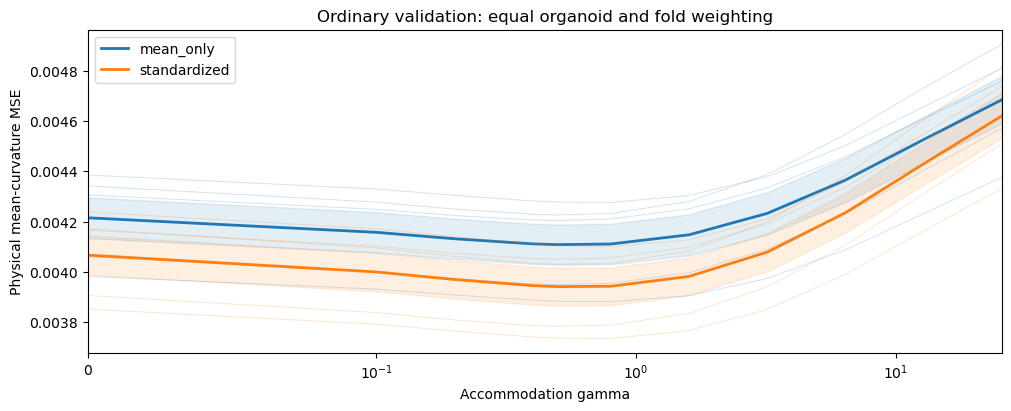

Saved completed run: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/conditional_scan_20261002_162217


In [7]:
gin_rows=globals().get('gin_rows',[])
scores=pd.concat([pd.DataFrame(score_rows),pd.DataFrame(gin_rows)],ignore_index=True)
scores.to_csv(RUN_DIR/'validation_mse.csv',index=False)
selected=[]
for (fold,mode,variant),group in pd.DataFrame(records).query("family == 'energy'").groupby(['fold','target_mode','variant']):
    best=group.loc[group.inner_mse.idxmin()]
    selected.append(dict(fold=int(fold),target_mode=mode,variant=variant,key=best.key,gamma=best.gamma,inner_mse=best.inner_mse))
pd.DataFrame(selected).to_csv(RUN_DIR/'selected_models.csv',index=False)
fig,ax=plt.subplots(figsize=(10,4),layout='constrained')
ordinary=scores[scores.cohort=='val']
if len(gammas)>1:
    for mode,d in ordinary.groupby('target_mode'):
        fold=d.groupby(['fold','gamma']).mse.mean().reset_index()
        mean=fold.groupby('gamma').mse.agg(['mean','sem']);x=mean.index.to_numpy()
        line,=ax.plot(x,mean['mean'],lw=2,label=mode)
        for _,f in fold.groupby('fold'):ax.plot(f.gamma,f.mse,c=line.get_color(),alpha=.2,lw=.7)
        ax.fill_between(x,mean['mean']-mean['sem'].fillna(0),mean['mean']+mean['sem'].fillna(0),alpha=.12,color=line.get_color())
    ax.set_xscale('symlog',linthresh=.1);ax.set_xlim(0,float(max(gammas)));ax.set_xlabel('Accommodation gamma')
else:
    for pos,((mode,variant),d) in enumerate(ordinary.groupby(['target_mode','variant'])):
        values=d.groupby('fold').mse.mean()
        ax.scatter(np.full(len(values),pos),values,s=14,alpha=.4,color='tab:blue')
        ax.errorbar(pos,values.mean(),yerr=values.sem() if len(values)>1 else 0,fmt='D',color='black')
    labels=[f'{m}\n{v}' for (m,v),_ in ordinary.groupby(['target_mode','variant'])]
    ax.set_xticks(range(len(labels)),labels,rotation=45,ha='right')
ax.set(ylabel='Physical mean-curvature MSE',title='Ordinary validation: equal organoid and fold weighting')
if len(gammas)>1:ax.legend()
fig.savefig(RUN_DIR/'training_validation.png',dpi=160);plt.show()
(RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(membership),conditional_moments=True),indent=2))
for filename in [f'experiments/training/{NOTEBOOK_NAME}.ipynb','src/models/curvature_energy.py','src/models/energy_ops.py','src/training/energy_fit.py','src/data/target_transforms.py']:
    dest=RUN_DIR/'source_snapshot'/filename;dest.parent.mkdir(parents=True,exist_ok=True);shutil.copy2(PROJECT_ROOT/filename,dest)
print('Saved completed run:',RUN_DIR)
